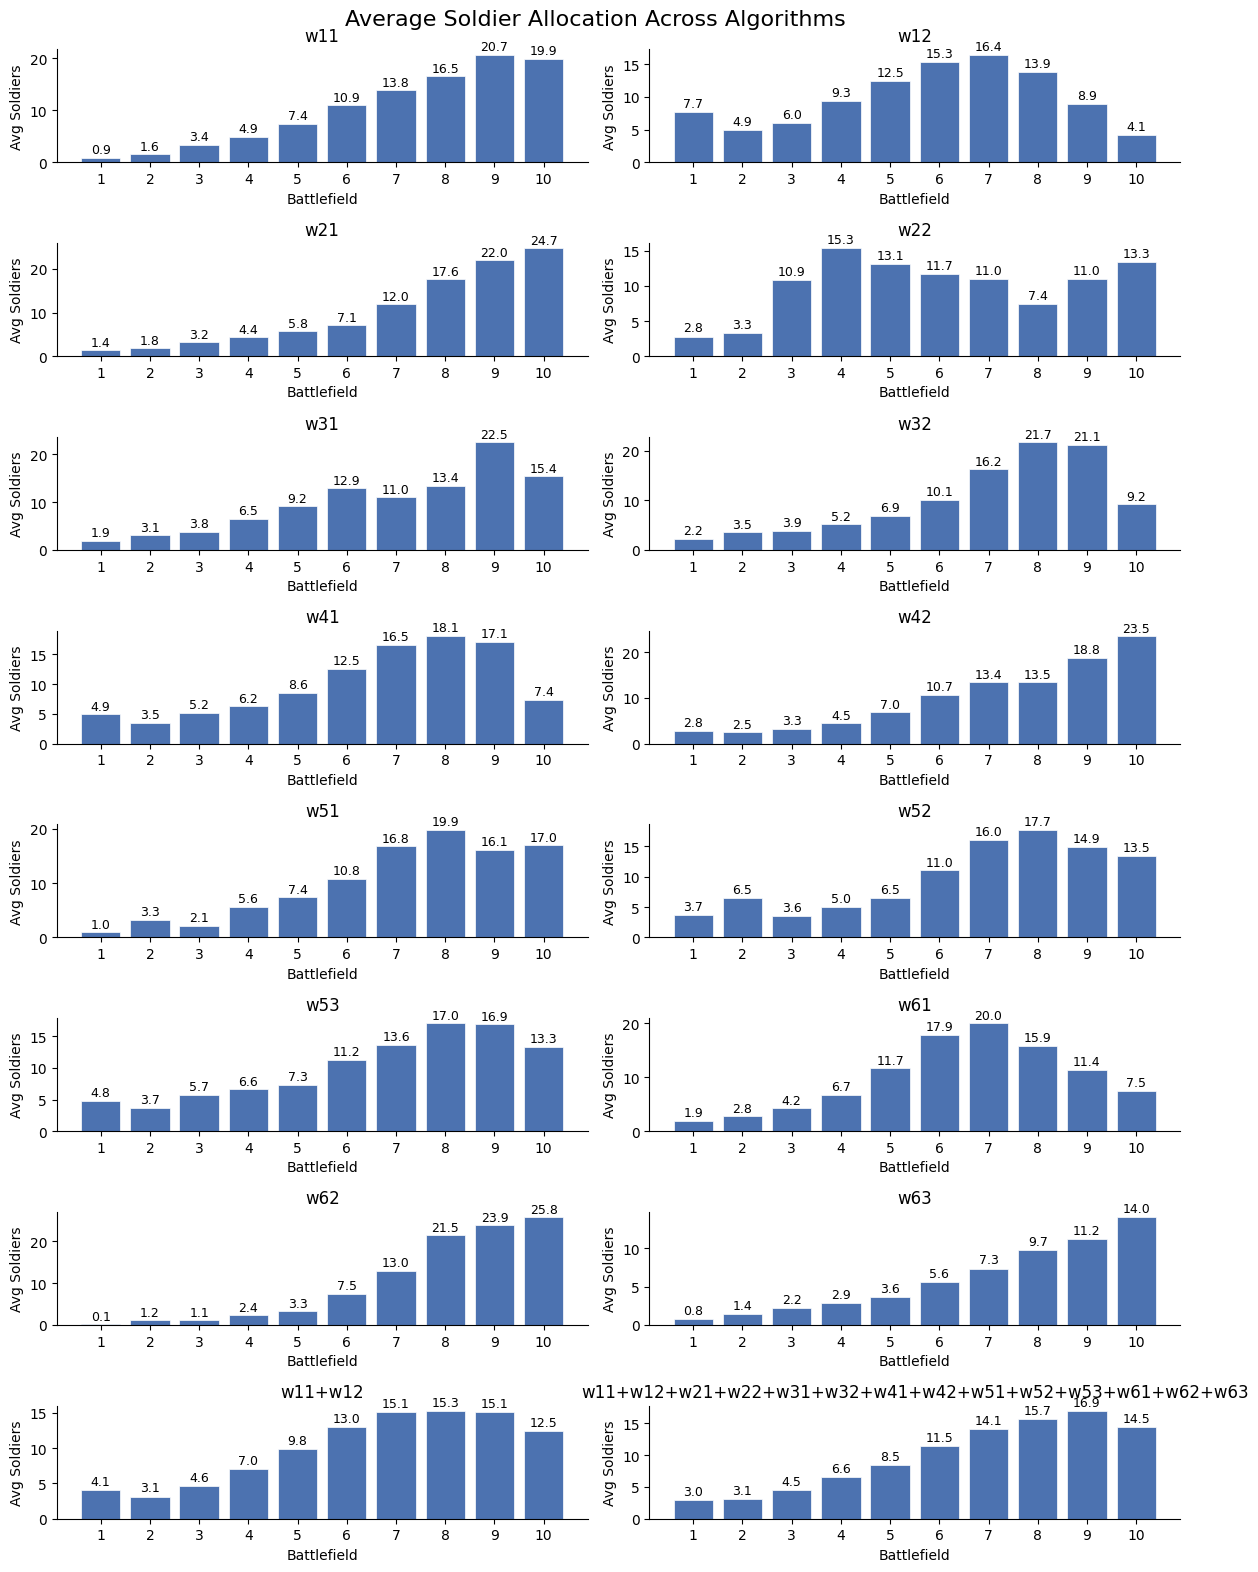

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import ast
from collections import Counter

def plot_avgs(scenarios: list[str], ax):

    # Load strategies
    strategies = []
    for s in scenarios:
        with open(f'algos/{s}_algos.txt', 'r') as f:
            for line in f:
                line = line.strip()
                if line:
                    strategies.append(ast.literal_eval(line))

    strategies = np.array(strategies)
    avg_allocation = strategies.mean(axis=0)

    battlefields = [f'{i+1}' for i in range(len(avg_allocation))]

    bars = ax.bar(battlefields, avg_allocation,
                  color='#4C72B0', edgecolor='white', linewidth=0.5)

    # Add value labels
    for bar, val in zip(bars, avg_allocation):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val:.1f}',
                ha='center', va='bottom', fontsize=9)

    ax.set_xlabel('Battlefield')
    ax.set_ylabel('Avg Soldiers')
    ax.set_title("+".join(scenarios))

    ax.spines[['top', 'right']].set_visible(False)

# Create subplot grid

scenarios = [["w11"], ["w12"], ["w21"], ["w22"], ["w31"], ["w32"], 
["w41"], ["w42"], ["w51"], ["w52"], ["w53"], ["w61"], ["w62"], ["w63"],
["w11", "w12"], "w11 w12 w21 w22 w31 w32 w41 w42 w51 w52 w53 w61 w62 w63".split()]

fig, axes = plt.subplots(8, 2, figsize=(12, 16))

for ax, scenario in zip(axes.flatten(), scenarios):
    plot_avgs(scenario, ax)

fig.suptitle("Average Soldier Allocation Across Algorithms", fontsize=16)

plt.tight_layout()
plt.show()

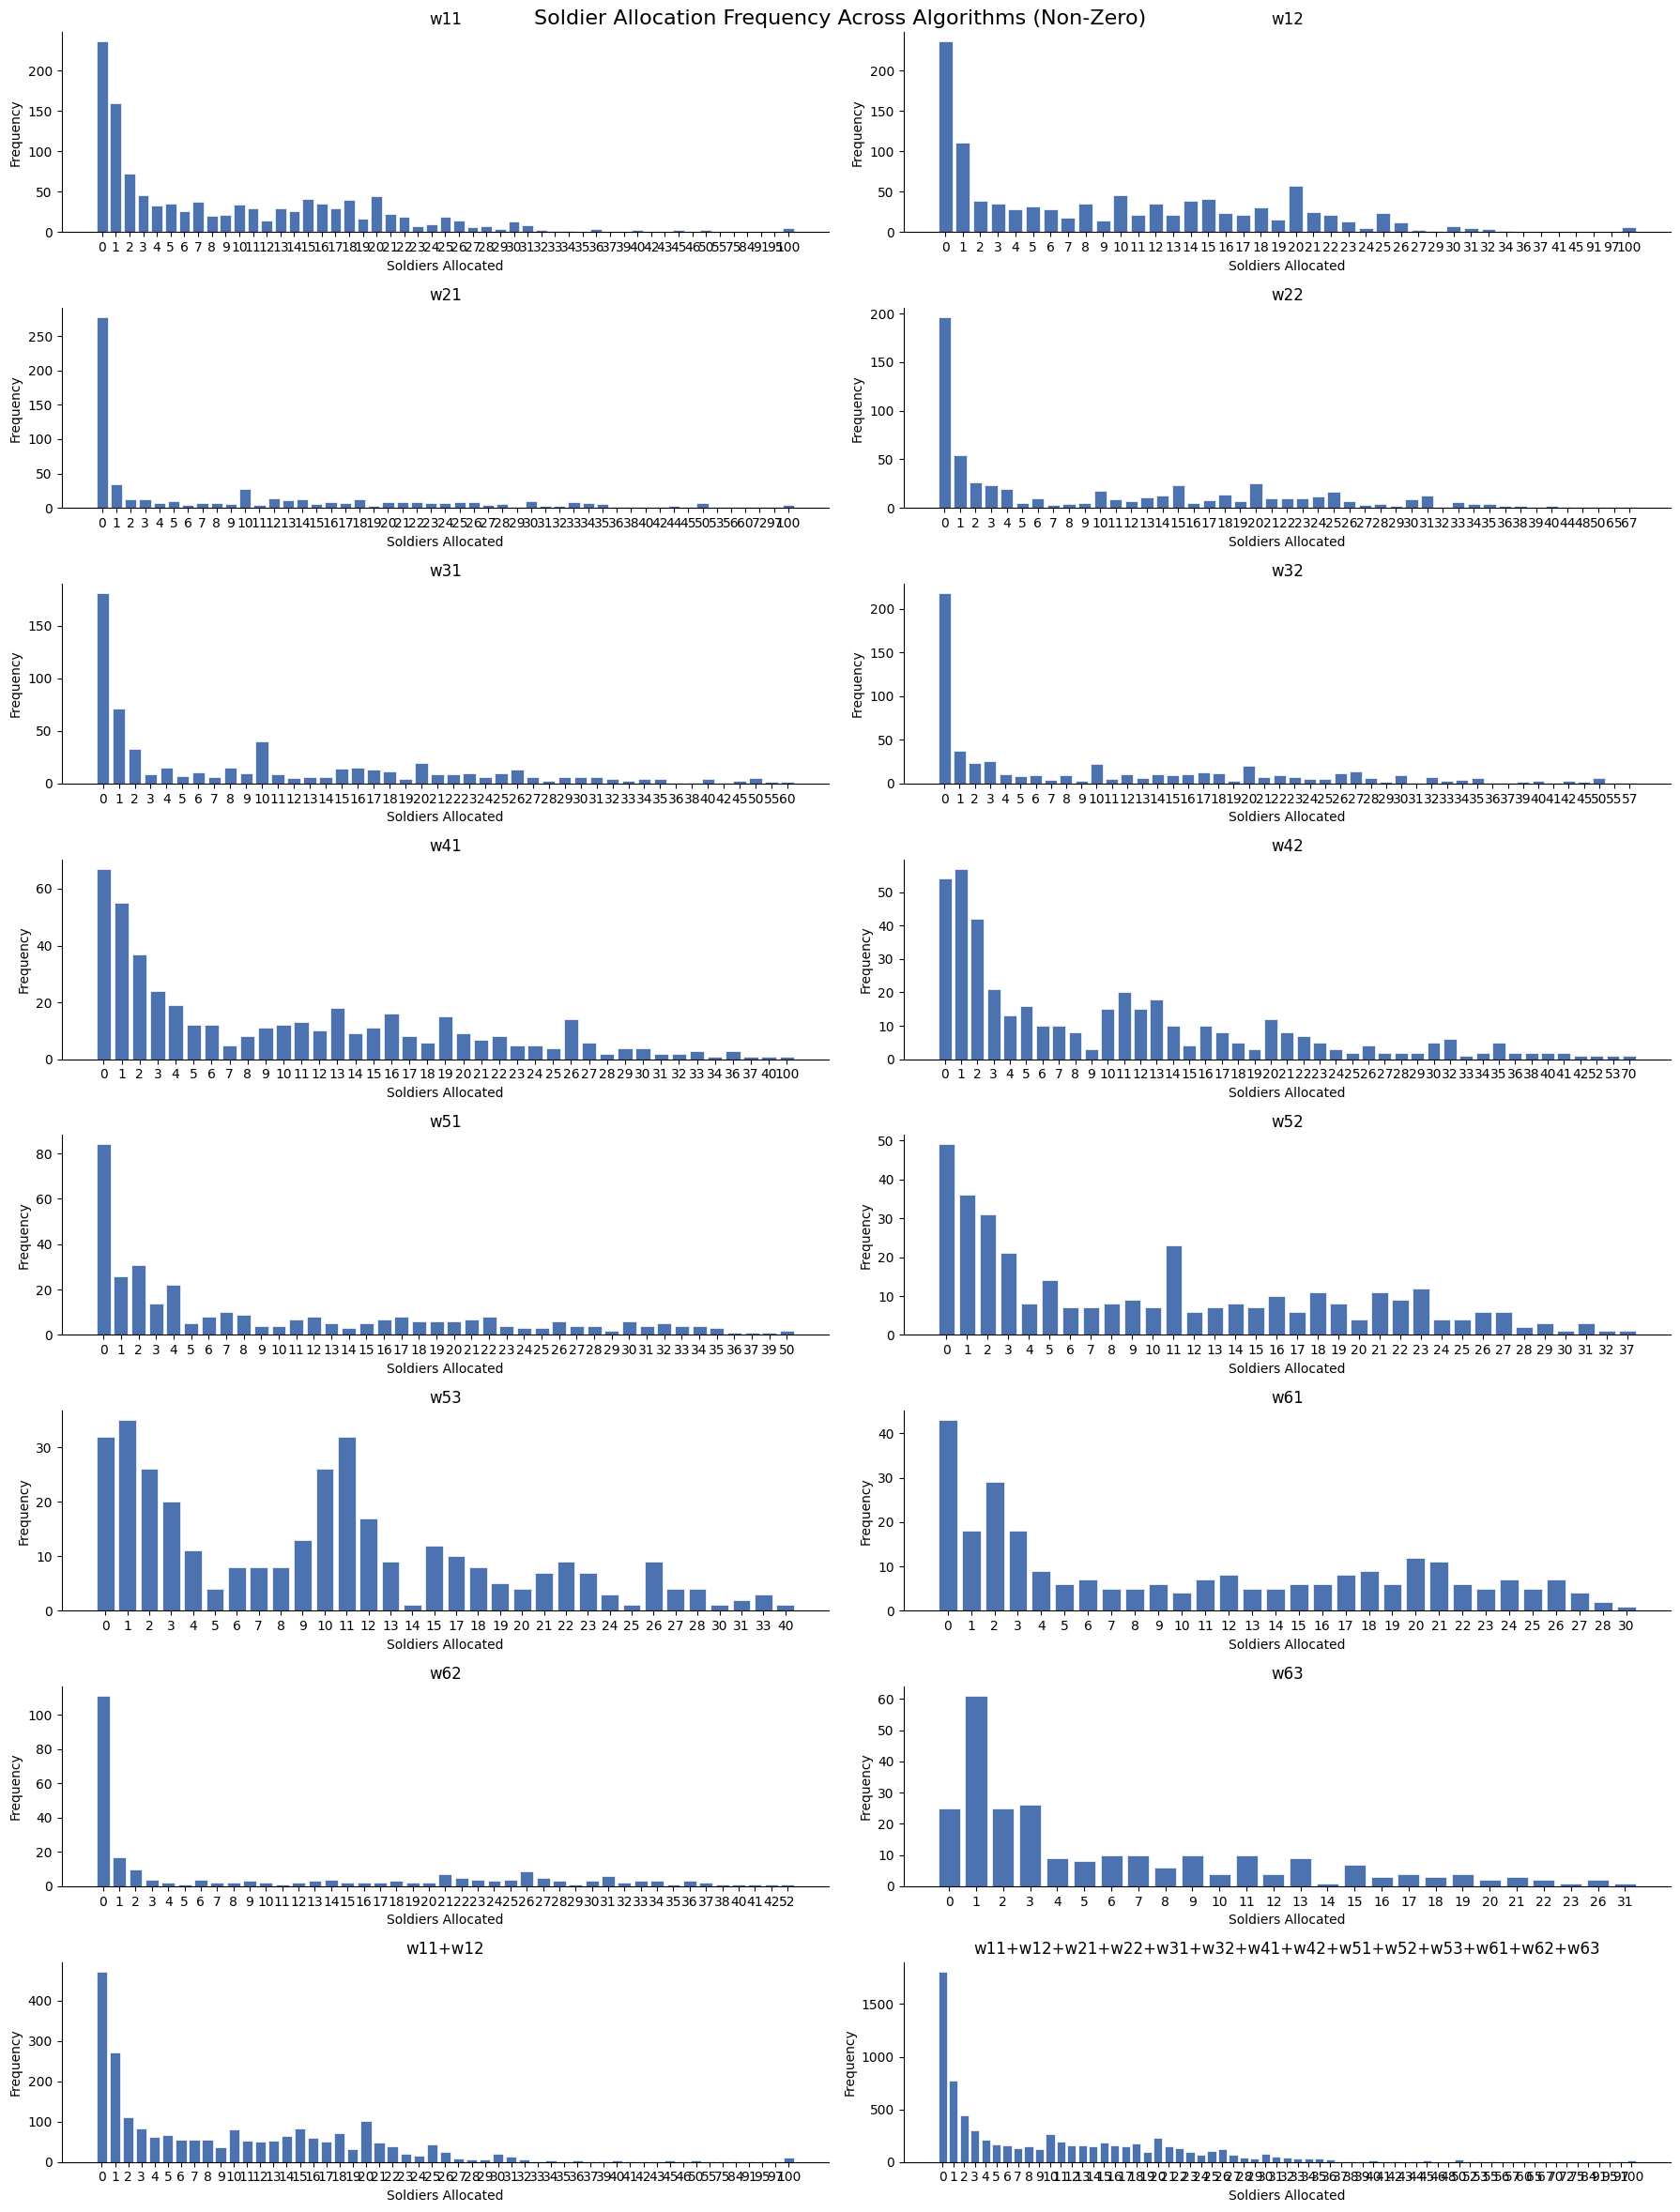

In [ ]:
from collections import defaultdict
import ast
import matplotlib.pyplot as plt

def plot_soldier_frequency(scenarios: list[str], ax):

    # Load strategies
    soldier_freq = defaultdict(int)
    for s in scenarios:
        with open(f"algos/{s}_algos.txt", "r") as f:
            for line in f:
                line = line.strip()
                if line:
                    for k in ast.literal_eval(line):
                            soldier_freq[k] += 1

    keys = sorted(soldier_freq.keys())
    values = [soldier_freq[k] for k in keys]

    # Convert keys to string for categorical bar chart
    keys_str = [str(k) for k in keys]

    bars = ax.bar(keys_str, values,
                  color="#4C72B0", edgecolor="white", linewidth=0.5)

    ax.set_xlabel("Soldiers Allocated")
    ax.set_ylabel("Frequency")
    ax.set_title("+".join(scenarios))

    ax.spines[["top", "right"]].set_visible(False)

scenarios_list = [["w11"], ["w12"], ["w21"], ["w22"], ["w31"], ["w32"], 
["w41"], ["w42"], ["w51"], ["w52"], ["w53"], ["w61"], ["w62"], ["w63"],
["w11", "w12"], "w11 w12 w21 w22 w31 w32 w41 w42 w51 w52 w53 w61 w62 w63".split()]

fig, axes = plt.subplots(8, 2, figsize=(18, 24))

for ax, scenario in zip(axes.flatten(), scenarios_list):
    plot_soldier_frequency(scenario, ax)

fig.suptitle("Soldier Allocation Frequency Across Algorithms", fontsize=16)

plt.tight_layout()
plt.show()
